In [4]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [9]:
tf = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

train_dl = DataLoader(
    datasets.ImageFolder("data/Training",tf),
    batch_size = 32,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

test_dl = DataLoader(
    datasets.ImageFolder("data/Testing",tf),
    batch_size = 32,
    shuffle = False,
    num_workers = 4,
    pin_memory = True
)

In [20]:
class tumor_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2),
            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2),
            nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(kernel_size = 2),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(in_features = 256, out_features = 4)
        ).to(device)
    def forward(self, x):
        return self.layer_stack(x)

In [21]:
model_1 = tumor_model()
optimizer = optim.Adam(params = model_1.parameters(), lr = 1e-4)
loss_fn = nn.CrossEntropyLoss()

In [23]:
model_1.train()

for epoch in range(25):
    running_loss = 0
    for x, y in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(model_1(x.to(device)), y.to(device))
        loss.backward()
        running_loss += loss
        optimizer.step()
    print(f"Epoch: {epoch} : Loss: {running_loss}")

Epoch: 0 : Loss: 137.3880615234375
Epoch: 1 : Loss: 88.95924377441406
Epoch: 2 : Loss: 70.55096435546875
Epoch: 3 : Loss: 58.54766845703125
Epoch: 4 : Loss: 48.876914978027344
Epoch: 5 : Loss: 41.08564758300781
Epoch: 6 : Loss: 35.62662124633789
Epoch: 7 : Loss: 29.429988861083984
Epoch: 8 : Loss: 27.280941009521484
Epoch: 9 : Loss: 22.52845573425293
Epoch: 10 : Loss: 20.003271102905273
Epoch: 11 : Loss: 16.1761474609375
Epoch: 12 : Loss: 15.927631378173828
Epoch: 13 : Loss: 13.62531852722168
Epoch: 14 : Loss: 11.009127616882324
Epoch: 15 : Loss: 9.616602897644043
Epoch: 16 : Loss: 9.057692527770996
Epoch: 17 : Loss: 8.195561408996582
Epoch: 18 : Loss: 7.151165008544922
Epoch: 19 : Loss: 6.544710636138916
Epoch: 20 : Loss: 6.139712333679199
Epoch: 21 : Loss: 5.6817626953125
Epoch: 22 : Loss: 5.306175708770752
Epoch: 23 : Loss: 4.378710746765137
Epoch: 24 : Loss: 4.030163764953613


In [26]:
model_1.eval()
test_loss, correct = 0.0, 0

with torch.no_grad():
    for x, y in test_dl:
        x, y = x.to(device), y.to(device)
        logits = model_1(x)
        test_loss += loss_fn(logits, y).item() * y.size(0)
        preds = logits.argmax(dim = 1)
        correct += (preds == y).sum().item()
test_loss /= len(test_dl.dataset)
accuracy = 100.0 * correct/len(test_dl.dataset)

print(f"Test loss: {test_loss} | Test accuracy: {accuracy}")

Test loss: 0.14569327051982614 | Test accuracy: 97.02517162471396


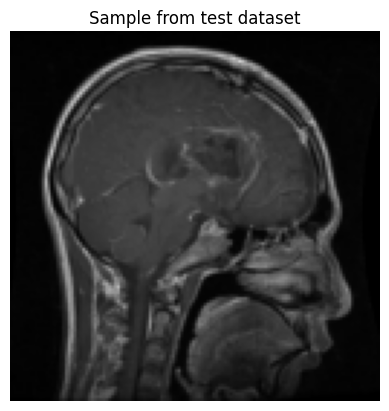

Predicted class : glioma
Ground Truth : glioma


In [34]:
import random
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

model_1.eval()

idx = random.randrange(len(test_dl.dataset))
img, label = test_dl.dataset[idx]

unnormalize  = img * 0.5 + 0.5
plt.imshow(to_pil_image(unnormalize))
plt.axis("off")
plt.title("Sample from test dataset")
plt.show()

with torch.no_grad():
    logits = model_1(img.unsqueeze(0).to(device))
    pred = logits.argmax(dim = 1).item()
class_names = test_dl.dataset.classes
print(f"Predicted class : {class_names[pred]}")
print(f"Ground Truth : {class_names[label]}")

In [37]:
import os

os.makedirs("models", exist_ok = "True")
torch.save(model_1.state_dict(), "models/model_1.pth")